In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle

In [2]:
!kaggle datasets download -d mdmahadihasan007/rv-dataset

Dataset URL: https://www.kaggle.com/datasets/mdmahadihasan007/rv-dataset
License(s): unknown
 99% 760M/768M [00:07<00:00, 298MB/s]
100% 768M/768M [00:07<00:00, 103MB/s]


In [3]:
import zipfile
zip_ref = zipfile.ZipFile("/content/rv-dataset.zip",'r')
zip_ref.extractall("/content")
zip_ref.close()

In [4]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 200
CHANNELS = 3

In [7]:
# transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

In [8]:
train_dataset = torchvision.datasets.ImageFolder(
    root = "/content/train_and_test/train",
    transform = transform
)

temp_dataset = torchvision.datasets.ImageFolder(
    root = "/content/train_and_test/test",
    transform = transform
)

In [9]:
class_names = train_dataset.classes
class_names

['10_Lal_Aush',
 '11_Jirashail',
 '12_Gutisharna',
 '13_Red_Cargo',
 '14_Najirshail',
 '15_Katari_Polao',
 '16_Lal_Biroi',
 '17_Chinigura_Polao',
 '18_Amon',
 '19_Shorna5',
 '1_Subol_Lota',
 '20_Lal_Binni',
 '2_Bashmoti',
 '3_Ganjiya',
 '4_Shampakatari',
 '5_Katarivog',
 '6_BR28',
 '7_BR29',
 '8_Paijam',
 '9_Bashful']

In [10]:
# Split datasets
val_size = int(0.50 * len(temp_dataset)) # 50%
test_size = len(temp_dataset) - val_size # 50%

val_dataset, test_dataset = torch.utils.data.random_split(
    temp_dataset,
    [val_size, test_size]
)

In [11]:
# Dataloader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    pin_memory = True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    pin_memory = True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2,
    pin_memory = True
)

In [12]:
len(train_loader), len(val_loader), len(test_loader)

(704, 71, 71)

In [13]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

def unnormalize(img_tensor, mean, std):
    img_tensor = img_tensor.clone()  # Clone the tensor to avoid modifying the original
    std = std.view(1,3,1,1) # N, C, H, W
    mean = mean.view(1,3,1,1)
    img_tensor = img_tensor * std + mean
    return img_tensor

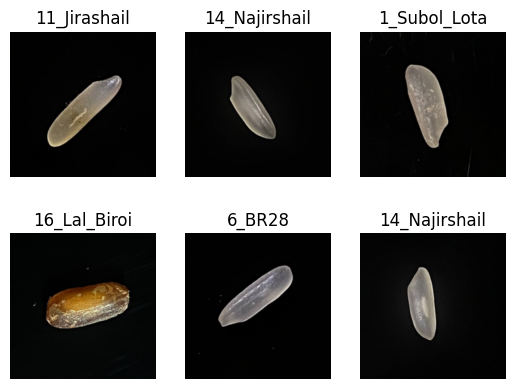

In [14]:
image, label = next(iter(train_loader))

for i in range(6):
    unnorm_img = unnormalize(image[i], mean, std)
    plt.subplot(2,3,i+1)
    plt.imshow(unnorm_img.squeeze().permute(1,2,0)) # C,H,W -> H,W,C
    plt.title(class_names[label[i]])
    plt.axis("off")

In [15]:
# load model
weights = torchvision.models.RegNet_X_16GF_Weights.DEFAULT
base_model = torchvision.models.regnet_x_16gf(weights = weights)

Downloading: "https://download.pytorch.org/models/regnet_x_16gf-ba3796d7.pth" to /root/.cache/torch/hub/checkpoints/regnet_x_16gf-ba3796d7.pth
100%|██████████| 208M/208M [00:04<00:00, 44.1MB/s]


In [16]:
# Freez layers
for param in base_model.parameters():
    param.requires_grad = False

In [17]:
!pip install torchinfo

In [18]:
from torchinfo import summary
summary(
    model = base_model,
    input_size = (BATCH_SIZE, CHANNELS, IMG_SIZE, IMG_SIZE),
    col_names = ["input_size", "output_size", "num_params", "trainable"],
    col_width = 20,
    row_settings = ["var_names"]
)

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
RegNet (RegNet)                                    [32, 3, 224, 224]    [32, 1000]           --                   False
├─SimpleStemIN (stem)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    └─Conv2d (0)                                  [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    └─BatchNorm2d (1)                             [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    └─ReLU (2)                                    [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
├─Sequential (trunk_output)                        [32, 32, 112, 112]   [32, 2048, 7, 7]     --                   False
│    └─AnyStage (block1)                           [32, 32, 112, 112]   [32, 256, 56, 56]    --                   False
│    │    └─ResBottleneckBlock (block1-

In [20]:
base_model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [21]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

base_model.fc = torch.nn.Sequential(
    torch.nn.Linear(in_features = 2048, out_features = 256),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features = 256, out_features = len(class_names))
)

In [22]:
summary(
    model = base_model,
    input_size = (BATCH_SIZE, CHANNELS, IMG_SIZE, IMG_SIZE),
    col_names = ["input_size", "output_size", "num_params", "trainable"],
    col_width = 20,
    row_settings = ["var_names"]
)

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
RegNet (RegNet)                                    [32, 3, 224, 224]    [32, 20]             --                   Partial
├─SimpleStemIN (stem)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    └─Conv2d (0)                                  [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    └─BatchNorm2d (1)                             [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    └─ReLU (2)                                    [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
├─Sequential (trunk_output)                        [32, 32, 112, 112]   [32, 2048, 7, 7]     --                   False
│    └─AnyStage (block1)                           [32, 32, 112, 112]   [32, 256, 56, 56]    --                   False
│    │    └─ResBottleneckBlock (block

In [23]:
# loss fucntion and optimizer

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = base_model.parameters(),
                             lr = 0.01)

In [24]:
# learning rate scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode = "min",
    factor = 0.1,
    patience = 3,
    cooldown = 0,
    min_lr = 0.00001,
)

# Early stopping
best_val_loss = float("inf")
patience = 5
patience_counter = 0

In [25]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = torch.compile(base_model)
model.to(device)

history = {
     "train_loss" : [],
     "train_acc" : [],
     "val_loss" : [],
     "val_acc" : []
 }

prev_lr = optimizer.param_groups[0]['lr']


In [26]:
# Training

for epoch in tqdm(range(EPOCHS)):

    # train_mode
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    # Iterate over batches
    for batch, (x_train,y_train) in enumerate(tqdm(train_loader)):
        x_train, y_train = x_train.to(device), y_train.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        y_preds = model(x_train)

        # Compute loss
        loss = criterion(y_preds, y_train)
        train_loss += loss.item()

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # calculate accuracy
        y_pred_class = torch.argmax(torch.softmax(y_preds, dim = 1), dim = 1)
        train_acc += (y_pred_class == y_train).sum().item() / len(y_preds)

    train_loss = train_loss / len(train_loader)
    train_acc = train_acc / len(train_loader)

    # val mode
    model.eval()
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)

            # forward
            val_preds = model(x_val)

            # loss
            loss = criterion(val_preds, y_val)
            val_loss += loss.item()

            val_pred_labels = val_preds.argmax(dim = 1)
            val_acc += (val_pred_labels == y_val).sum().item() / len(val_pred_labels)

    val_loss = val_loss / len(val_loader)
    val_acc = val_acc / len(val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history["val_acc"].append(val_acc)

    # learning rate scheduler
    lr_scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    if current_lr != prev_lr:
        print(f"Learning rate changed from {prev_lr} to {current_lr}")
        prev_lr = current_lr

    # check early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        print(f"New best model found at epoch {epoch+1}")
        torch.save(model.state_dict(), "best_model.pth")

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    # print
    print(f"\nEpoch: {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | learning rate: {current_lr:.5f}\n")

# Best Model Load
model.load_state_dict(torch.load('best_model.pth'))

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/704 [00:00<?, ?it/s]

New best model found at epoch 1

Epoch: 1/200 | Train Loss: 0.4512 | Train Acc: 0.8600 | Val Loss: 0.2167 | Val Acc: 0.9243 | learning rate: 0.01000



  0%|          | 0/704 [00:00<?, ?it/s]

New best model found at epoch 2

Epoch: 2/200 | Train Loss: 0.2463 | Train Acc: 0.9223 | Val Loss: 0.2066 | Val Acc: 0.9349 | learning rate: 0.01000



...

  0%|          | 0/704 [00:00<?, ?it/s]

Learning rate changed from 0.001 to 0.0001

Epoch: 19/200 | Train Loss: 0.0187 | Train Acc: 0.9937 | Val Loss: 0.0591 | Val Acc: 0.9837 | learning rate: 0.00010



  0%|          | 0/704 [00:00<?, ?it/s]

Early stopping at epoch 20


<All keys matched successfully>

In [28]:
def evaluate(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    with torch.no_grad():
        for batch, (image, label) in enumerate(tqdm(data_loader)):
            image, label = image.to(device), label.to(device)

            preds = model(image)

            loss = loss_fn(preds, label)
            total_loss += loss.item()

            pred_labels = preds.argmax(dim = 1)
            total_acc += (pred_labels == label).sum().item() / len(pred_labels)

    total_loss /= len(data_loader)
    total_acc /= len(data_loader)

    print(f"Loss: {total_loss:.4f} | Accuracy: {total_acc:.4f}")

In [29]:
evaluate(model, test_loader, criterion)

  0%|          | 0/71 [00:00<?, ?it/s]

Loss: 0.0609 | Accuracy: 0.9833


In [30]:
evaluate(model, train_loader, criterion)

  0%|          | 0/704 [00:00<?, ?it/s]

Loss: 0.0042 | Accuracy: 0.9984


In [32]:
import pandas as pd

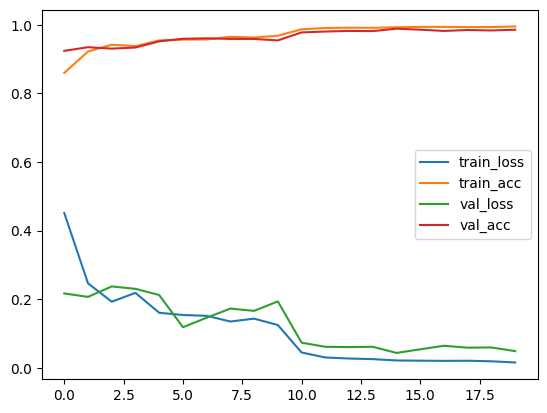

In [33]:
pd.DataFrame(history).plot()
plt.show()